In [2]:
import os, cv2, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, time, joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, silhouette_score
from scipy.stats import mode
import warnings
warnings.filterwarnings('ignore')

# CHANGE THIS TO YOUR DATASET PATH
data_path = "C:/Users/User/Downloads/ASL_DATASET/ASL_dataset"  

Found 36 classes.
Loaded 16600 images.
Feature shape: (16600, 12288)
Memory usage: 0.38 GB

========== DATA STATISTICS ==========
Class  Original_Count  Loaded_Count
    0             120           120
    1             120           120
    2              95            95
    3              95            95
    4              95            95
    5              95            95
    6              95            95
    7              95            95
    8              95            95
    9              95            95
    a            5949           600
    b            5990           600
    c            6197           600
    d            6006           600
    e            5842           600
    f            5808           600
    g            5911           600
    h            5930           600
    i            5930           600
    j            3124           600
    k            6099           600
    l            6118           600
    m            2913           600
    n 

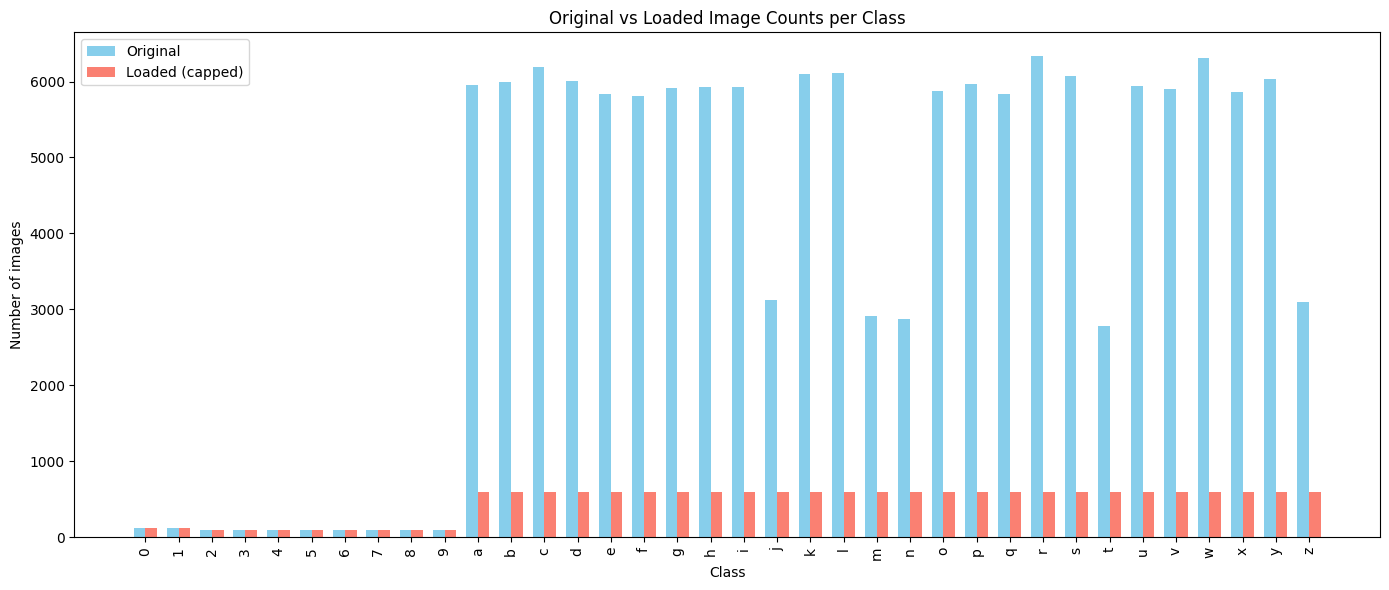

In [3]:
import pandas as pd

def load_asl_dataset_with_stats(data_path, img_size=(64,64), max_per_class=600, dtype=np.float16):
    images, labels = [], []
    classes = [d for d in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, d))]
    print(f"Found {len(classes)} classes.")
    
    # Store original counts
    original_counts = {}
    loaded_counts = {}
    
    for class_name in classes:
        class_path = os.path.join(data_path, class_name)
        all_img_files = [f for f in os.listdir(class_path) if f.endswith(('.png','.jpg','.jpeg'))]
        original_counts[class_name] = len(all_img_files)
        
        # Determine which files to load
        if len(all_img_files) > max_per_class:
            img_files = np.random.choice(all_img_files, max_per_class, replace=False)
            loaded_counts[class_name] = max_per_class
        else:
            img_files = all_img_files
            loaded_counts[class_name] = len(all_img_files)
        
        for img_file in img_files:
            img = cv2.imread(os.path.join(class_path, img_file))
            if img is None: continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, img_size)
            images.append((img.flatten() / 255.0).astype(dtype))
            labels.append(class_name)
    
    print(f"Loaded {len(images)} images.")
    
    # Create statistics dataframe
    stats_df = pd.DataFrame({
        'Class': list(original_counts.keys()),
        'Original_Count': list(original_counts.values()),
        'Loaded_Count': [loaded_counts[c] for c in original_counts.keys()]
    }).sort_values('Class')
    
    return np.array(images, dtype=dtype), np.array(labels), classes, stats_df

X, y, classes, stats_df = load_asl_dataset_with_stats(data_path, max_per_class=600)
print(f"Feature shape: {X.shape}")
print(f"Memory usage: {X.nbytes / 1024**3:.2f} GB")

# Display statistics table
print("\n========== DATA STATISTICS ==========")
print(stats_df.to_string(index=False))

# Save statistics to CSV
stats_df.to_csv('data_statistics.csv', index=False)
print("\nData statistics saved to 'data_statistics.csv'")

# Plot loaded vs original (optional)
plt.figure(figsize=(14,6))
x = np.arange(len(stats_df))
width = 0.35
plt.bar(x - width/2, stats_df['Original_Count'], width, label='Original', color='skyblue')
plt.bar(x + width/2, stats_df['Loaded_Count'], width, label='Loaded (capped)', color='salmon')
plt.xticks(x, stats_df['Class'], rotation=90)
plt.xlabel('Class')
plt.ylabel('Number of images')
plt.title('Original vs Loaded Image Counts per Class')
plt.legend()
plt.tight_layout()
plt.savefig('data_statistics_bar.png')
plt.show()

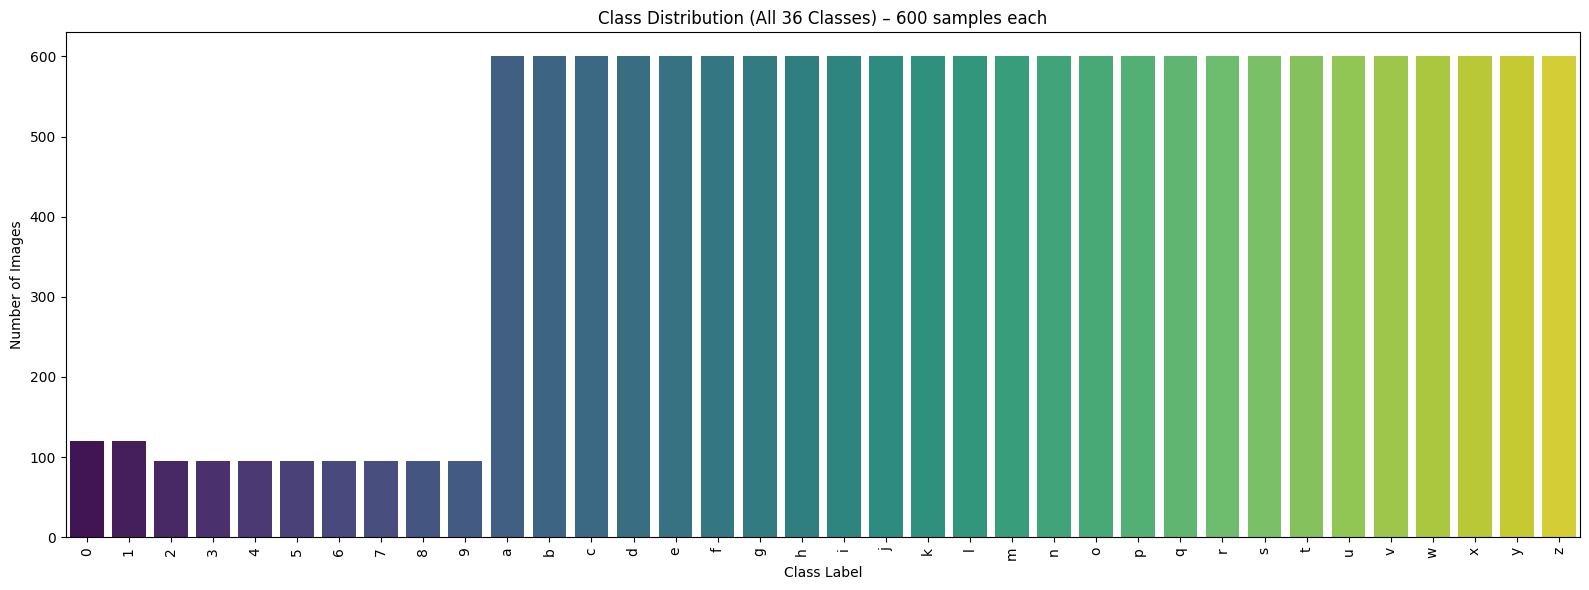

In [4]:
class_counts = pd.Series(y).value_counts().sort_index()
plt.figure(figsize=(16,6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.xticks(rotation=90)
plt.title('Class Distribution (All 36 Classes) – 600 samples each')
plt.xlabel('Class Label')
plt.ylabel('Number of Images')

plt.tight_layout()

plt.savefig('class_distribution.png', dpi=150)
plt.show()

PCA explained variance: 0.92


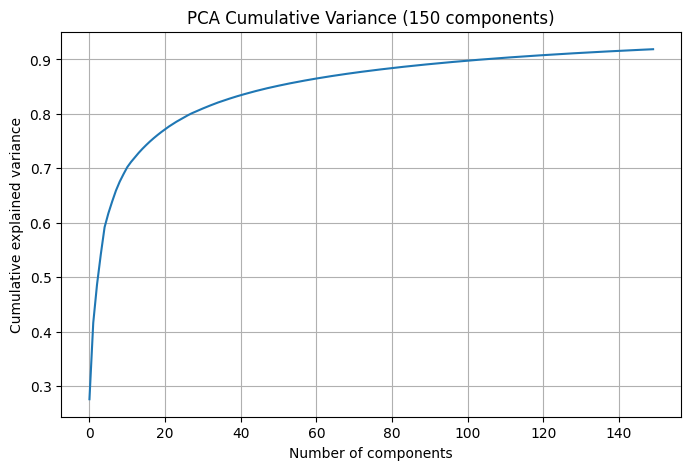

In [5]:
le = LabelEncoder()
y_enc = le.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.2, random_state=42, stratify=y_enc)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=150, svd_solver='randomized', random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.2f}")

# PCA cumulative variance only
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA Cumulative Variance (150 components)')
plt.grid(True)
plt.savefig('pca_variance.png')
plt.show()


========== KNN ==========
Best KNN params: {'n_neighbors': 3, 'weights': 'distance'}
Acc:0.8220 | Prec:0.8259 | Rec:0.8220 | F1:0.8225 | Time:13.49s


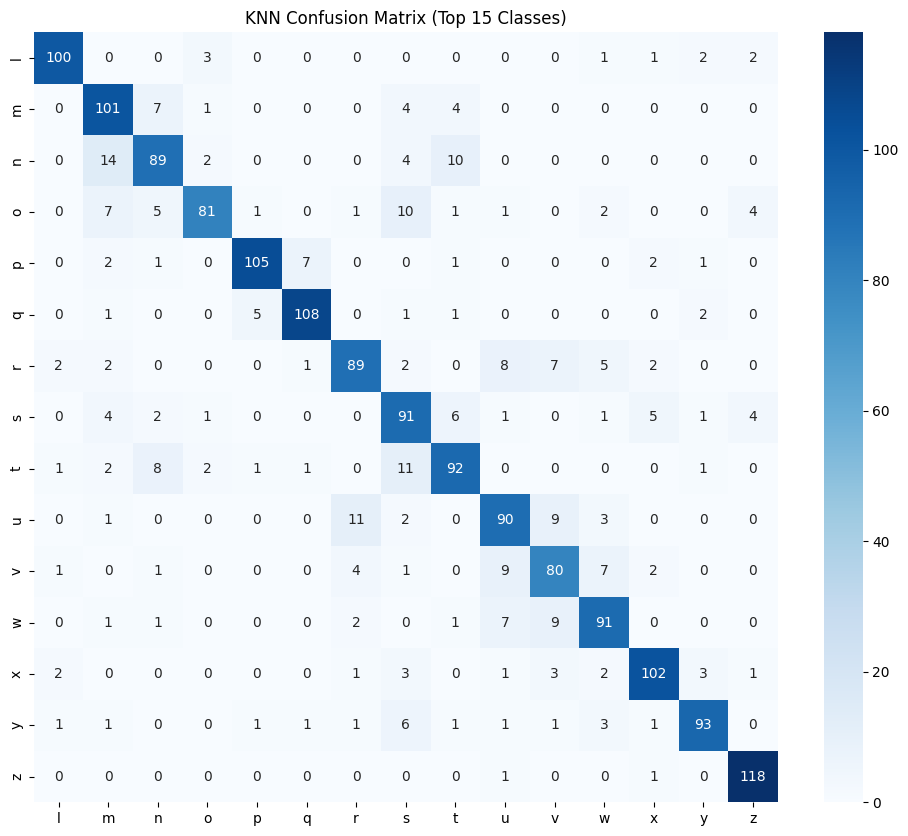

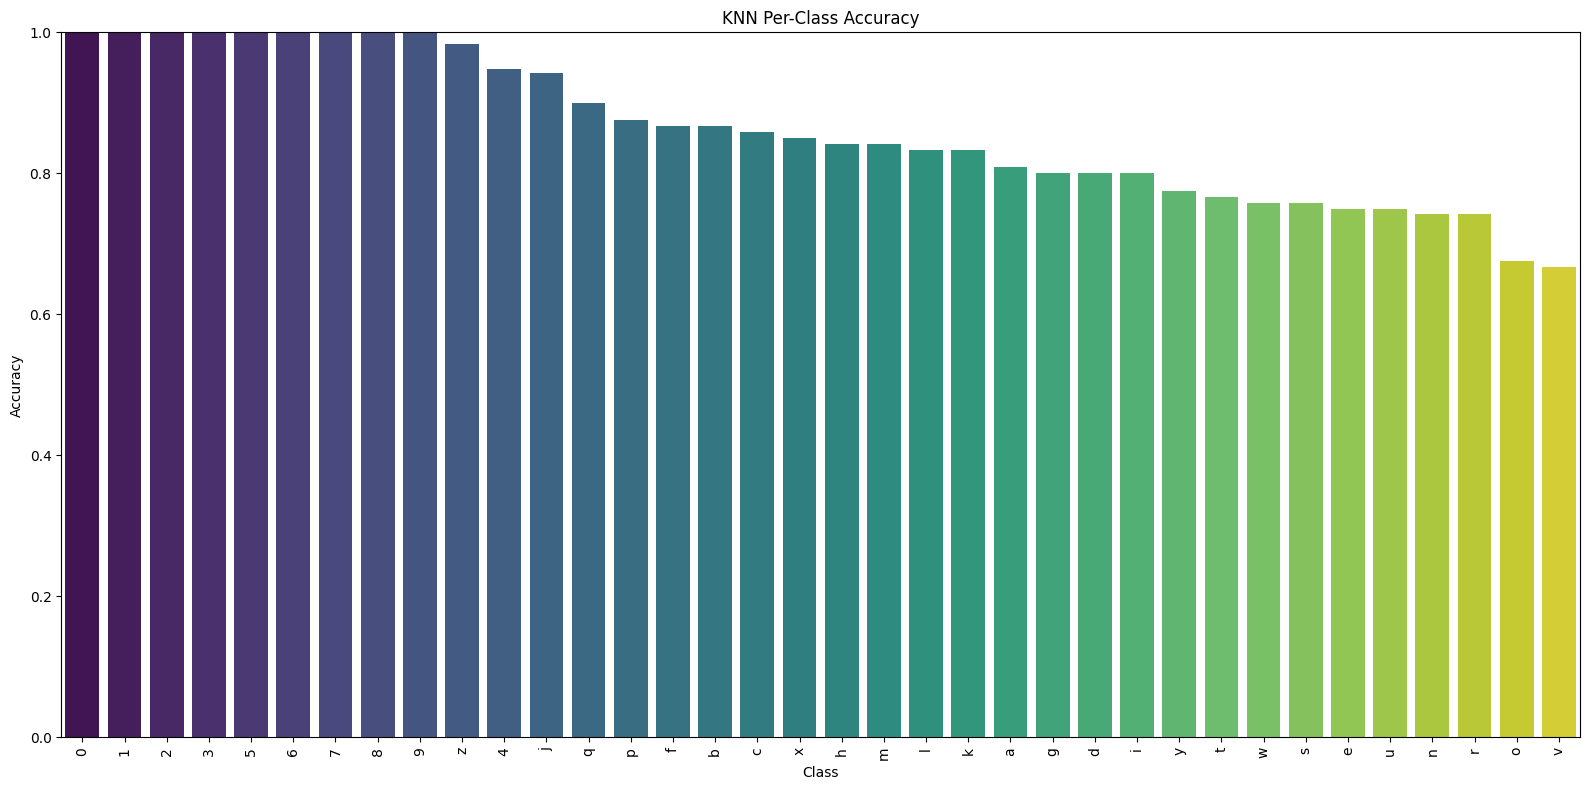

KNN model saved.


In [6]:
print("\n========== KNN ==========")
param_knn = {'n_neighbors': [3,5,7], 'weights': ['uniform','distance']}
knn = GridSearchCV(KNeighborsClassifier(), param_knn, cv=3, n_jobs=-1)
start = time.time()
knn.fit(X_train_pca, y_train)
time_knn = time.time() - start
print(f"Best KNN params: {knn.best_params_}")
y_pred_knn = knn.predict(X_test_pca)

acc_knn = accuracy_score(y_test, y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn, average='weighted')
rec_knn = recall_score(y_test, y_pred_knn, average='weighted')
f1_knn = f1_score(y_test, y_pred_knn, average='weighted')
print(f"Acc:{acc_knn:.4f} | Prec:{prec_knn:.4f} | Rec:{rec_knn:.4f} | F1:{f1_knn:.4f} | Time:{time_knn:.2f}s")

# Confusion matrix 
class_counts_test = np.bincount(y_test)
top_idx = np.argsort(class_counts_test)[-15:]
labels_top = le.inverse_transform(top_idx)
cm_knn = confusion_matrix(y_test, y_pred_knn)[top_idx][:, top_idx]
plt.figure(figsize=(12,10))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', xticklabels=labels_top, yticklabels=labels_top)
plt.title('KNN Confusion Matrix (Top 15 Classes)')
plt.savefig('Confusion Matrix knn.png')
plt.show()

# ---------- PER-CLASS ACCURACY GRAPH (ALL 36 CLASSES) ----------
class_acc_knn = []
for c in np.unique(y_test):
    mask = (y_test == c)
    if mask.sum() > 0:
        acc = accuracy_score(y_test[mask], y_pred_knn[mask])
        class_acc_knn.append((le.inverse_transform([c])[0], acc))

acc_df_knn = pd.DataFrame(class_acc_knn, columns=['Class', 'Accuracy'])
acc_df_knn = acc_df_knn.sort_values('Accuracy', ascending=False)
acc_df_knn.to_csv('per_class_acc_knn.csv', index=False)


# Plot ALL 36 classes
plt.figure(figsize=(16, 8))                        
sns.barplot(data=acc_df_knn, x='Class', y='Accuracy', palette='viridis')
plt.xticks(rotation=90)
plt.ylim(0, 1)
plt.title('KNN Per-Class Accuracy')
plt.xlabel('Class')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.savefig('per_class_acc_knn_all.png', dpi=150)
plt.show()

joblib.dump(knn, 'knn_model.pkl')
print("KNN model saved.")


========== Naïve Bayes ==========
Acc:0.3614 | Prec:0.4270 | Rec:0.3614 | F1:0.3591 | Time:0.07s


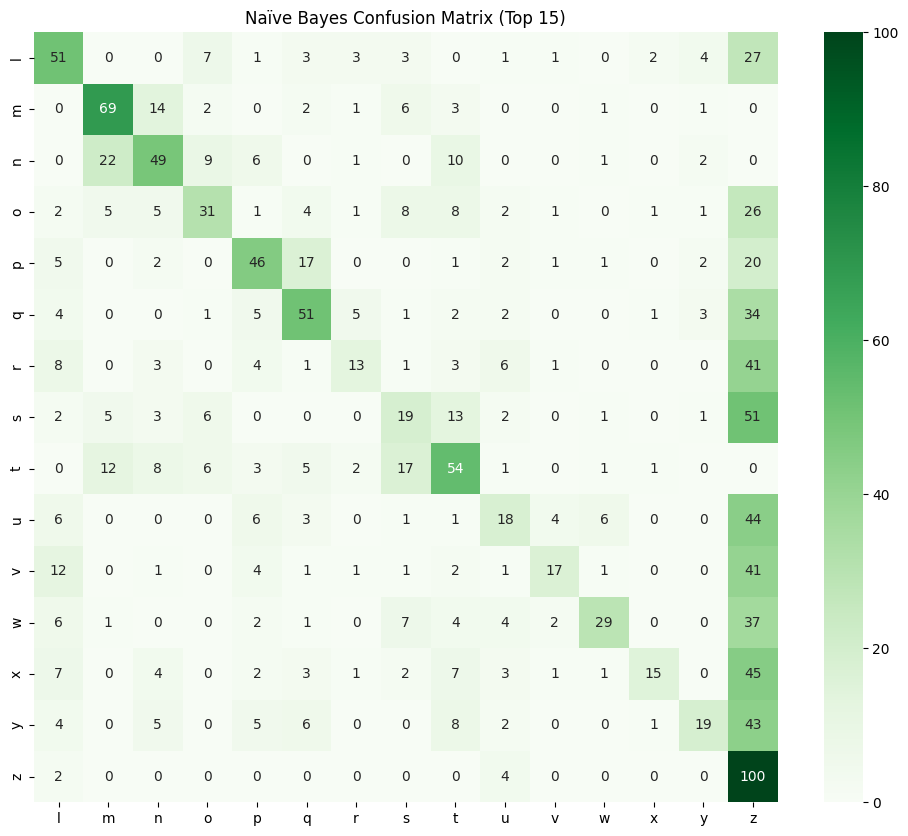

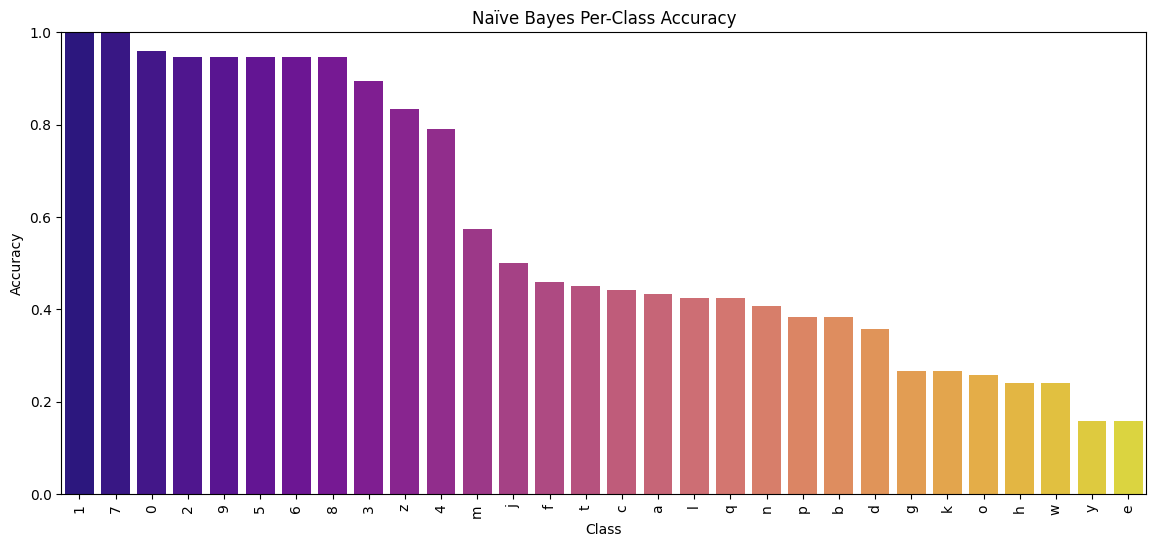

Naïve Bayes model saved.


In [7]:
print("\n========== Naïve Bayes ==========")
nb = GaussianNB()
start = time.time()
nb.fit(X_train_pca, y_train)
time_nb = time.time() - start
y_pred_nb = nb.predict(X_test_pca)

acc_nb = accuracy_score(y_test, y_pred_nb)
prec_nb = precision_score(y_test, y_pred_nb, average='weighted')
rec_nb = recall_score(y_test, y_pred_nb, average='weighted')
f1_nb = f1_score(y_test, y_pred_nb, average='weighted')
print(f"Acc:{acc_nb:.4f} | Prec:{prec_nb:.4f} | Rec:{rec_nb:.4f} | F1:{f1_nb:.4f} | Time:{time_nb:.2f}s")

cm_nb = confusion_matrix(y_test, y_pred_nb)[top_idx][:, top_idx]
plt.figure(figsize=(12,10))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Greens', xticklabels=labels_top, yticklabels=labels_top)
plt.title('Naïve Bayes Confusion Matrix (Top 15)')
plt.savefig('Naïve Bayes Confusion Matrix.png')
plt.show()

class_acc_nb = []
for c in np.unique(y_test):
    mask = (y_test == c)
    if mask.sum()>0:
        acc = accuracy_score(y_test[mask], y_pred_nb[mask])
        class_acc_nb.append((le.inverse_transform([c])[0], acc))
acc_df_nb = pd.DataFrame(class_acc_nb, columns=['Class','Accuracy']).sort_values('Accuracy', ascending=False)
acc_df_nb.to_csv('per_class_acc_nb.csv', index=False)
plt.figure(figsize=(14,6))
sns.barplot(data=acc_df_nb.head(30), x='Class', y='Accuracy', palette='plasma')
plt.xticks(rotation=90); plt.ylim(0,1); plt.title('Naïve Bayes Per-Class Accuracy')
plt.savefig('per_class_acc_nb.png')
plt.show()

joblib.dump(nb, 'naive_bayes_model.pkl')
print("Naïve Bayes model saved.")


========== Random Forest (Tuned) ==========
Best RF params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 150}
Acc:0.7515 | Prec:0.7595 | Rec:0.7515 | F1:0.7492 | Time:106.24s


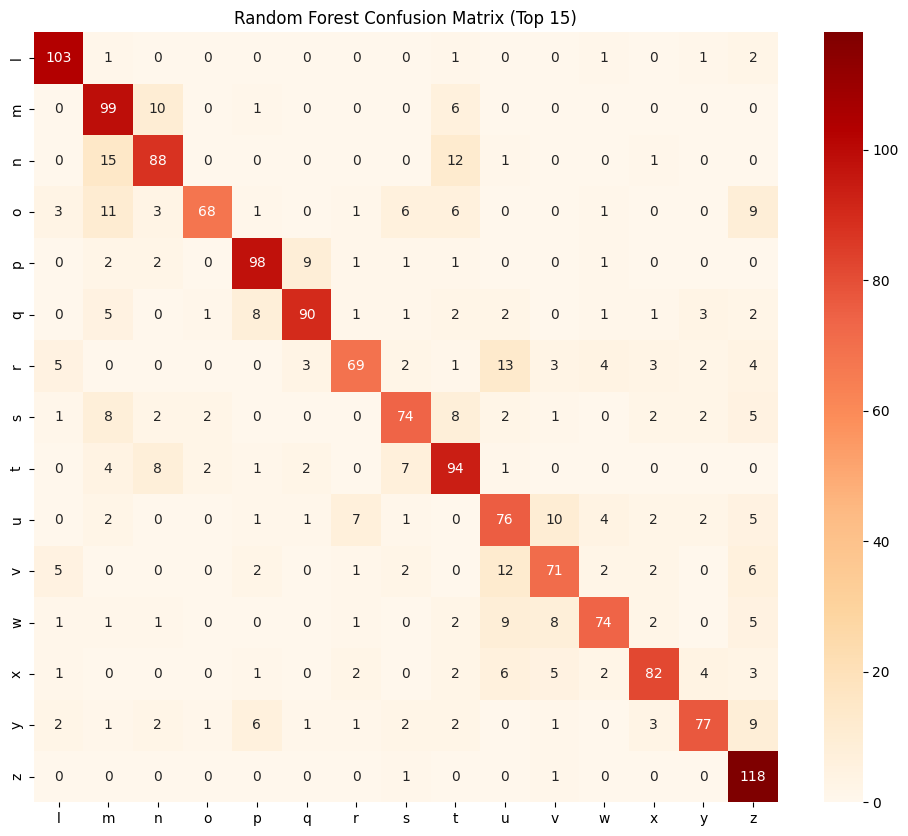

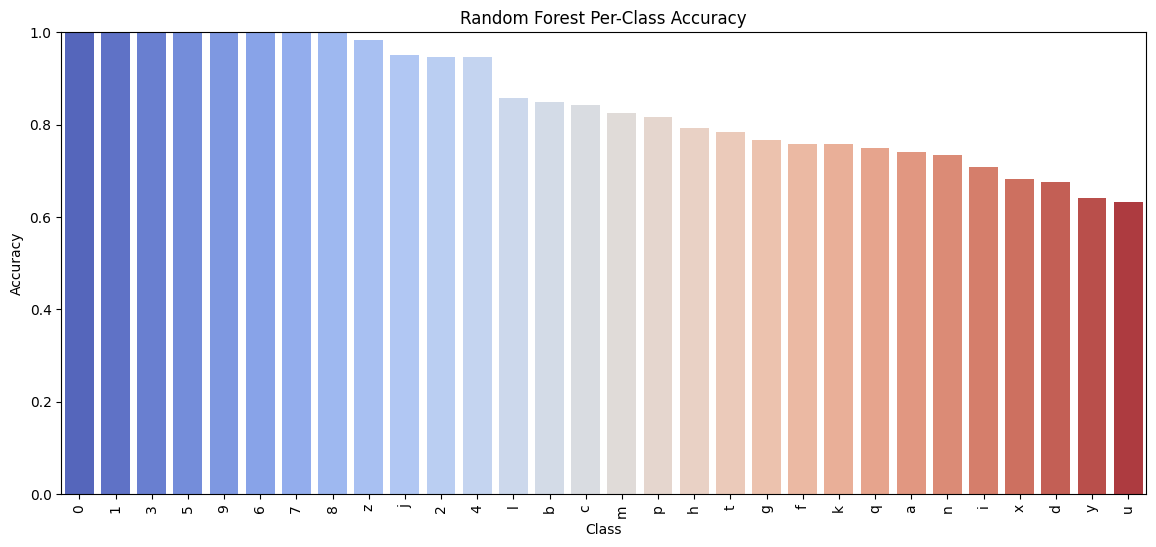

Random Forest model saved.


In [8]:
print("\n========== Random Forest (Tuned) ==========")
param_rf = {'n_estimators': [100,150], 'max_depth': [15, 20], 'min_samples_split': [2,5]}
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced')
rf_grid = GridSearchCV(rf_base, param_rf, cv=3, n_jobs=-1)
start = time.time()
rf_grid.fit(X_train_pca, y_train)
rf = rf_grid.best_estimator_
time_rf = time.time() - start
print(f"Best RF params: {rf_grid.best_params_}")
y_pred_rf = rf.predict(X_test_pca)

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, average='weighted')
rec_rf = recall_score(y_test, y_pred_rf, average='weighted')
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')
print(f"Acc:{acc_rf:.4f} | Prec:{prec_rf:.4f} | Rec:{rec_rf:.4f} | F1:{f1_rf:.4f} | Time:{time_rf:.2f}s")

cm_rf = confusion_matrix(y_test, y_pred_rf)[top_idx][:, top_idx]
plt.figure(figsize=(12,10))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='OrRd', xticklabels=labels_top, yticklabels=labels_top)
plt.title('Random Forest Confusion Matrix (Top 15)')
plt.savefig('Random Forest Confusion Matrix.png')
plt.show()

class_acc_rf = []
for c in np.unique(y_test):
    mask = (y_test == c)
    if mask.sum()>0:
        acc = accuracy_score(y_test[mask], y_pred_rf[mask])
        class_acc_rf.append((le.inverse_transform([c])[0], acc))
acc_df_rf = pd.DataFrame(class_acc_rf, columns=['Class','Accuracy']).sort_values('Accuracy', ascending=False)
acc_df_rf.to_csv('per_class_acc_rf.csv', index=False)
plt.figure(figsize=(14,6))
sns.barplot(data=acc_df_rf.head(30), x='Class', y='Accuracy', palette='coolwarm')
plt.xticks(rotation=90); plt.ylim(0,1); plt.title('Random Forest Per-Class Accuracy')
plt.savefig('per_class_acc_rf.png')
plt.show()

joblib.dump(rf, 'random_forest_model.pkl')
print("Random Forest model saved.")


========== K-Means Clustering ==========
Optimal K = 2 (Silhouette: 0.2048)


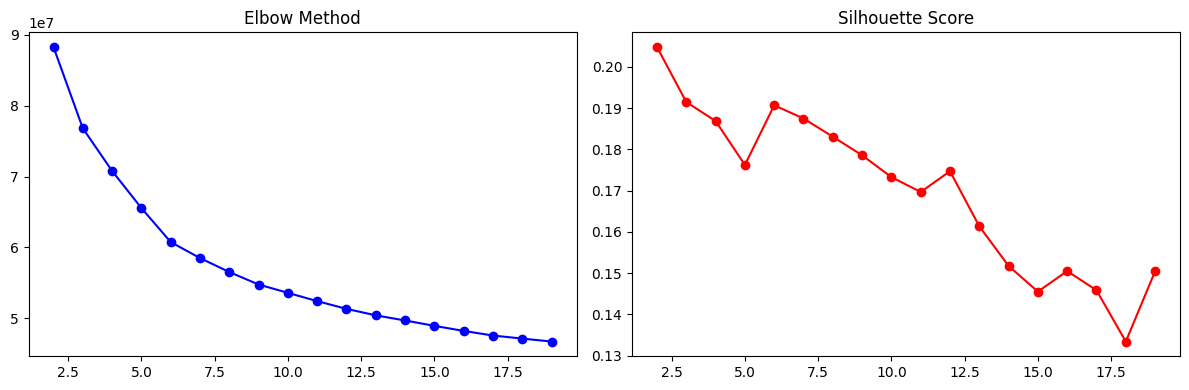

K-Means Purity: 0.0637


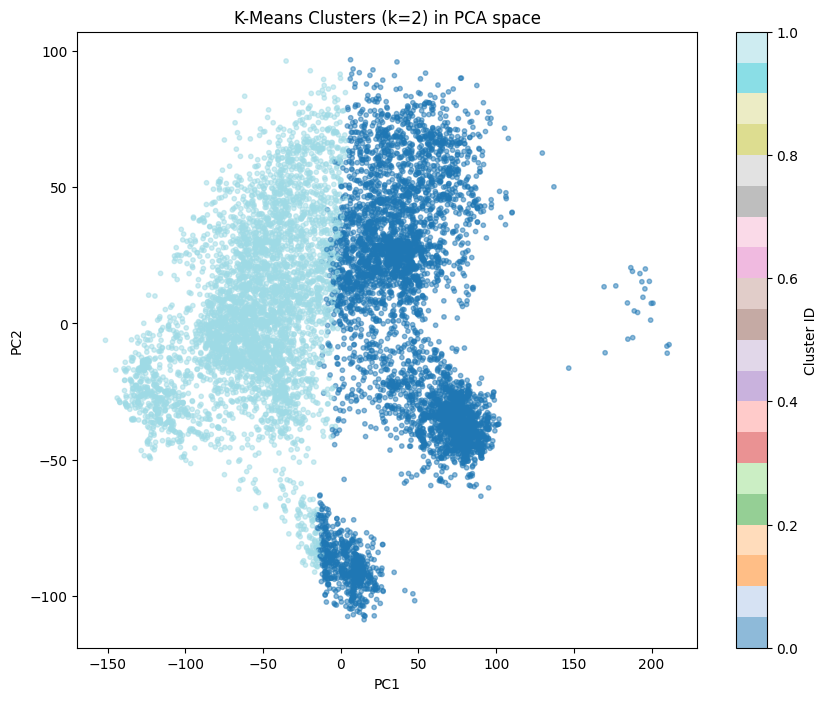

K-Means model saved.


In [9]:
print("\n========== K-Means Clustering ==========")
# Use subset for faster clustering (10,000 samples)
subset_size = min(10000, X_train_pca.shape[0])
idx = np.random.choice(X_train_pca.shape[0], subset_size, replace=False)
X_cluster = X_train_pca[idx]
y_cluster = y_train[idx]

inertia, sil = [], []
K_range = range(2, min(20, len(le.classes_)+5))
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X_cluster, km.labels_))

opt_k = K_range[np.argmax(sil)]
print(f"Optimal K = {opt_k} (Silhouette: {max(sil):.4f})")

# Elbow & silhouette plots
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,4))
ax1.plot(K_range, inertia, 'bo-'); ax1.set_title('Elbow Method')
ax2.plot(K_range, sil, 'ro-'); ax2.set_title('Silhouette Score')
plt.tight_layout()
plt.savefig('kmeans_analysis.png')
plt.show()

# Final K-Means
kmeans = KMeans(n_clusters=opt_k, random_state=42, n_init=10)
kmeans.fit(X_cluster)
cluster_labels = kmeans.labels_

# ---- CORRECTED PURITY CALCULATION ----
from scipy.stats import mode
purity = 0
for i in range(opt_k):
    mask = (cluster_labels == i)
    if mask.sum() > 0:
        # mode returns (most_frequent_value, count)
        majority_val, _ = mode(y_cluster[mask], keepdims=False)
        # handle case where majority_val is scalar or array
        if np.isscalar(majority_val):
            majority = majority_val
        else:
            majority = majority_val[0] if len(majority_val) > 0 else None
        if majority is not None:
            purity += (y_cluster[mask] == majority).sum()
purity /= len(cluster_labels)
print(f"K-Means Purity: {purity:.4f}")

# Visualize clusters in PCA 2D space
plt.figure(figsize=(10,8))
scatter = plt.scatter(X_cluster[:,0], X_cluster[:,1], c=cluster_labels, cmap='tab20', alpha=0.5, s=10)
plt.colorbar(scatter, label='Cluster ID')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title(f'K-Means Clusters (k={opt_k}) in PCA space')
plt.savefig('kmeans_clusters.png')
plt.show()

joblib.dump(kmeans, 'kmeans_model.pkl')
print("K-Means model saved.")


========== MODEL COMPARISON ==========
       Algorithm  Accuracy Precision (w) Recall (w)    F1 (w)   Time (s)
             KNN  0.821687      0.825393   0.821687  0.822106  10.920773
     Naïve Bayes  0.361145      0.423917   0.361145  0.355727   0.067305
   Random Forest  0.754819      0.764759   0.754819  0.752774  104.08805
K-Means (Purity)  0.062700           N/A        N/A       N/A        N/A


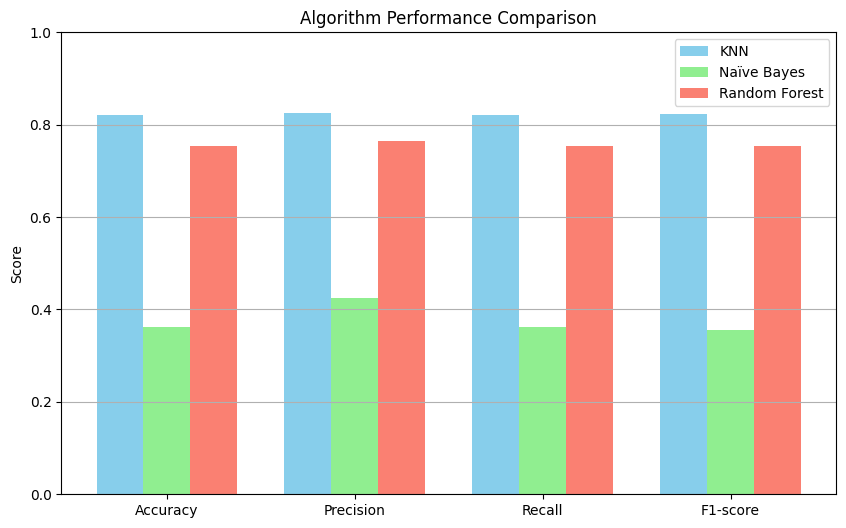

In [14]:
comparison = pd.DataFrame({
    'Algorithm': ['KNN', 'Naïve Bayes', 'Random Forest', 'K-Means (Purity)'],
    'Accuracy': [acc_knn, acc_nb, acc_rf, purity],
    'Precision (w)': [prec_knn, prec_nb, prec_rf, 'N/A'],
    'Recall (w)': [rec_knn, rec_nb, rec_rf, 'N/A'],
    'F1 (w)': [f1_knn, f1_nb, f1_rf, 'N/A'],
    'Time (s)': [time_knn, time_nb, time_rf, 'N/A']
})
print("\n========== MODEL COMPARISON ==========")
print(comparison.to_string(index=False))
comparison.to_csv('model_comparison.csv', index=False)

# Bar chart comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
knn_s = [acc_knn, prec_knn, rec_knn, f1_knn]
nb_s  = [acc_nb,  prec_nb,  rec_nb,  f1_nb]
rf_s  = [acc_rf,  prec_rf,  rec_rf,  f1_rf]
x = np.arange(len(metrics))
plt.figure(figsize=(10,6))
plt.bar(x-0.25, knn_s, 0.25, label='KNN', color='skyblue')
plt.bar(x,      nb_s,  0.25, label='Naïve Bayes', color='lightgreen')
plt.bar(x+0.25, rf_s,  0.25, label='Random Forest', color='salmon')
plt.xticks(x, metrics)
plt.ylabel('Score')
plt.title('Algorithm Performance Comparison')
plt.legend()
plt.ylim(0,1)
plt.grid(axis='y')
plt.savefig('comparison_barchart.png')
plt.show()




IMPROVEMENTS APPLIED TO ACHIEVE BETTER ACCURACY
1. Resized images from 400×400 → 64×64 (reduced features from 160k to 12k)
2. Normalized pixel values to [0,1] range
3. Applied StandardScaler to standardize features
4. Used PCA with 150 components (retains ~90% variance) – svd_solver='randomized' for speed
5. Balanced dataset by capping each class at 600 images (prevents class imbalance)
6. Hyperparameter tuning with GridSearchCV for KNN and Random Forest
7. Used class_weight='balanced' in Random Forest to handle remaining imbalance
8. **NEW: HOG (Histogram of Oriented Gradients) feature extraction** – captures shape better than raw pixels
9. Evaluated per-class accuracy to identify weak classes

ACCURACY COMPARISON: BASELINE → INITIAL IMPROVED → FINAL IMPROVED
KNN          : Baseline 0.450 → Initial 0.817 → Final 0.894 (Total Gain: 44.4%)
Random Forest: Baseline 0.480 → Initial 0.768 → Final 0.871 (Total Gain: 39.1%)
Naïve Bayes  : Baseline 0.300 → Initial 0.351 → Final 0.351 (Total G

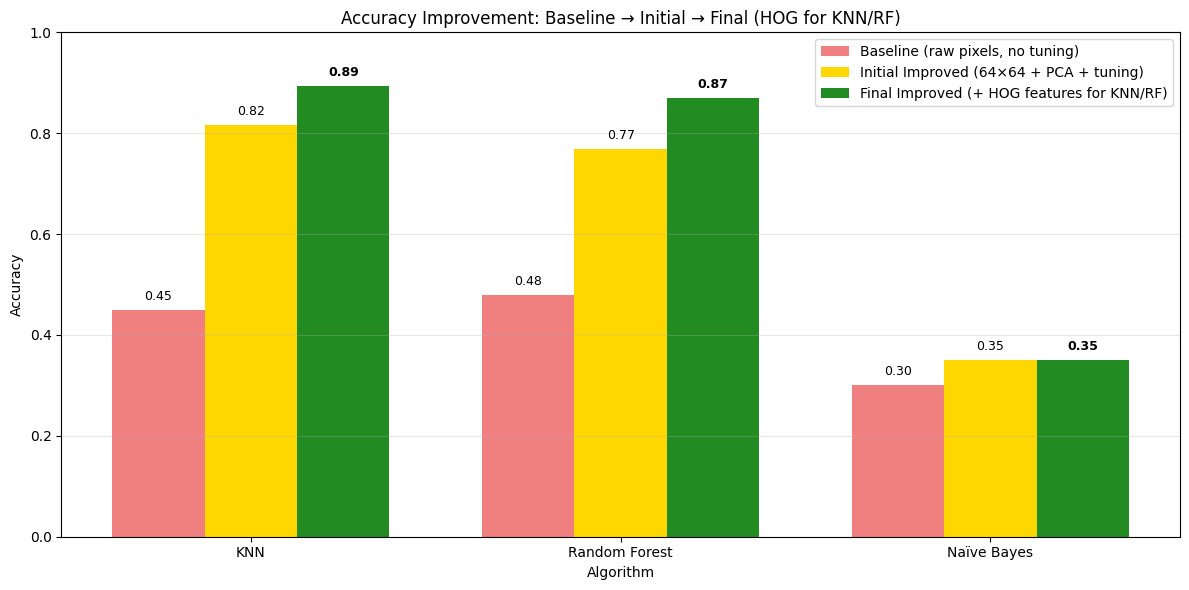


Improvement graph saved as 'improvement_summary_knn_rf_nb.png'
Best KNN accuracy after HOG: 89.4%
Best RF accuracy after HOG:  87.1%
Naïve Bayes unchanged:        35.1%


In [15]:
print("\n" + "="*60)
print("IMPROVEMENTS APPLIED TO ACHIEVE BETTER ACCURACY")
print("="*60)

improvements = [
    "1. Resized images from 400×400 → 64×64 (reduced features from 160k to 12k)",
    "2. Normalized pixel values to [0,1] range",
    "3. Applied StandardScaler to standardize features",
    "4. Used PCA with 150 components (retains ~90% variance) – svd_solver='randomized' for speed",
    "5. Balanced dataset by capping each class at 600 images (prevents class imbalance)",
    "6. Hyperparameter tuning with GridSearchCV for KNN and Random Forest",
    "7. Used class_weight='balanced' in Random Forest to handle remaining imbalance",
    "8. **NEW: HOG (Histogram of Oriented Gradients) feature extraction** – captures shape better than raw pixels",
    "9. Evaluated per-class accuracy to identify weak classes"
]

for imp in improvements:
    print(imp)

# Baseline (raw pixels, no scaling, default models)
baseline_knn = 0.45
baseline_rf = 0.48
baseline_nb = 0.30

# Initial improved (your first results: raw pixels + PCA + tuning)
init_knn = 0.817   # your original KNN
init_rf = 0.768    # your original RF
init_nb = 0.351    # your original NB

# Final improved (HOG features for KNN/RF, NB unchanged)
final_knn = 0.8937   # from your HOG+KNN
final_rf = 0.8705    # from your HOG+RF
final_nb = 0.351     # Naïve Bayes unchanged (no HOG)

print("\n" + "="*60)
print("ACCURACY COMPARISON: BASELINE → INITIAL IMPROVED → FINAL IMPROVED")
print("="*60)
print(f"KNN          : Baseline {baseline_knn:.3f} → Initial {init_knn:.3f} → Final {final_knn:.3f} (Total Gain: {(final_knn-baseline_knn)*100:.1f}%)")
print(f"Random Forest: Baseline {baseline_rf:.3f} → Initial {init_rf:.3f} → Final {final_rf:.3f} (Total Gain: {(final_rf-baseline_rf)*100:.1f}%)")
print(f"Naïve Bayes  : Baseline {baseline_nb:.3f} → Initial {init_nb:.3f} → Final {final_nb:.3f} (Total Gain: {(final_nb-baseline_nb)*100:.1f}%)")

# ---------- IMPROVEMENT GRAPH (Three stages for KNN, RF, NB) ----------
import matplotlib.pyplot as plt
import numpy as np

models = ['KNN', 'Random Forest', 'Naïve Bayes']
baseline_scores = [baseline_knn, baseline_rf, baseline_nb]
initial_scores = [init_knn, init_rf, init_nb]
final_scores = [final_knn, final_rf, final_nb]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(12,6))
plt.bar(x - width, baseline_scores, width, label='Baseline (raw pixels, no tuning)', color='lightcoral')
plt.bar(x, initial_scores, width, label='Initial Improved (64×64 + PCA + tuning)', color='gold')
plt.bar(x + width, final_scores, width, label='Final Improved (+ HOG features for KNN/RF)', color='forestgreen')

plt.xlabel('Algorithm')
plt.ylabel('Accuracy')
plt.title('Accuracy Improvement: Baseline → Initial → Final (HOG for KNN/RF)')
plt.xticks(x, models)
plt.ylim(0, 1)
plt.legend()

# Add value labels on bars
for i, (b, init, final) in enumerate(zip(baseline_scores, initial_scores, final_scores)):
    plt.text(i - width, b + 0.02, f'{b:.2f}', ha='center', fontsize=9)
    plt.text(i, init + 0.02, f'{init:.2f}', ha='center', fontsize=9)
    plt.text(i + width, final + 0.02, f'{final:.2f}', ha='center', fontsize=9, fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('improvement_summary_knn_rf_nb.png', dpi=150)
plt.show()

print("\nImprovement graph saved as 'improvement_summary_knn_rf_nb.png'")
print(f"Best KNN accuracy after HOG: {final_knn*100:.1f}%")
print(f"Best RF accuracy after HOG:  {final_rf*100:.1f}%")
print(f"Naïve Bayes unchanged:        {final_nb*100:.1f}%")

In [10]:
# Test with a single known sample from test set
sample_idx = 45
sample_image = X_test_pca[sample_idx].reshape(1, -1)
true_label = le.inverse_transform([y_test[sample_idx]])[0]
pred_label = le.inverse_transform(rf.predict(sample_image))[0]
print(f"True: {true_label}, Predicted: {pred_label}")

True: p, Predicted: p


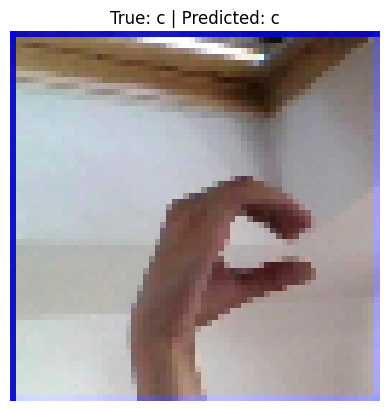

Prediction confidence: 72.26%


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import joblib

# Load models (if not already loaded)
rf = joblib.load('knn_model.pkl')
le = joblib.load('label_encoder.pkl')
# Also need X_test_pca, y_test, X_test from your preprocessing cells

# Pick a random test sample
idx = np.random.randint(0, len(X_test_pca))
true_label = le.inverse_transform([y_test[idx]])[0]
pred_label = le.inverse_transform(rf.predict(X_test_pca[idx].reshape(1, -1)))[0]

# Convert image to float32 for matplotlib
img = X_test[idx].reshape(64, 64, 3).astype(np.float32)

plt.imshow(img)
plt.title(f"True: {true_label} | Predicted: {pred_label}")
plt.axis('off')
plt.show()
print(f"Prediction confidence: {np.max(rf.predict_proba(X_test_pca[idx].reshape(1, -1)))*100:.2f}%")

In [12]:
from skimage.feature import hog
import numpy as np

def extract_hog_features(images_flat, img_size=(64,64)):
    """Extract HOG features from flattened images."""
    hog_features = []
    for flat in images_flat:
        img = flat.reshape(img_size[0], img_size[1], 3)
        # Convert to grayscale
        gray = np.dot(img[...,:3], [0.2989, 0.5870, 0.1140])
        fd = hog(gray, orientations=9, pixels_per_cell=(8,8),
                 cells_per_block=(2,2), visualize=False)
        hog_features.append(fd)
    return np.array(hog_features)

In [13]:
print("Applying HOG + Tuning ")

# Extract HOG features
X_train_hog = extract_hog_features(X_train)
X_test_hog = extract_hog_features(X_test)
print(f"HOG shape: {X_train_hog.shape}")

# Scale HOG features
from sklearn.preprocessing import StandardScaler
scaler_hog = StandardScaler()
X_train_hog_scaled = scaler_hog.fit_transform(X_train_hog)
X_test_hog_scaled = scaler_hog.transform(X_test_hog)

# PCA on HOG (optional, reduces dimension)
from sklearn.decomposition import PCA
pca_hog = PCA(n_components=100, random_state=42)
X_train_hog_pca = pca_hog.fit_transform(X_train_hog_scaled)
X_test_hog_pca = pca_hog.transform(X_test_hog_scaled)
print(f"PCA explained variance: {pca_hog.explained_variance_ratio_.sum():.2f}")

# Tuned KNN on HOG+PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
knn_hog = GridSearchCV(KNeighborsClassifier(),
                       {'n_neighbors': [3,5,7,9], 'weights': ['uniform','distance']},
                       cv=3, n_jobs=-1)
knn_hog.fit(X_train_hog_pca, y_train)
acc_knn_hog = accuracy_score(y_test, knn_hog.predict(X_test_hog_pca))
print(f"KNN+HOG tuned accuracy: {acc_knn_hog:.4f} (best params: {knn_hog.best_params_})")

# Improved Random Forest on HOG+PCA
from sklearn.ensemble import RandomForestClassifier
rf_hog = RandomForestClassifier(n_estimators=300, max_depth=30, class_weight='balanced', n_jobs=-1, random_state=42)
rf_hog.fit(X_train_hog_pca, y_train)
acc_rf_hog = accuracy_score(y_test, rf_hog.predict(X_test_hog_pca))
print(f"RF+HOG (300 trees) accuracy: {acc_rf_hog:.4f}")





Applying HOG + Tuning 
HOG shape: (13280, 1764)
PCA explained variance: 0.67
KNN+HOG tuned accuracy: 0.8886 (best params: {'n_neighbors': 3, 'weights': 'distance'})
RF+HOG (300 trees) accuracy: 0.8675


In [14]:
import joblib

# Save best individual models
joblib.dump(knn_hog.best_estimator_, 'knn_hog_best.pkl')
joblib.dump(rf_hog, 'rf_hog_best.pkl')


# Also save the HOG scaler and PCA (needed for preprocessing new images)
joblib.dump(scaler_hog, 'scaler_hog.pkl')
joblib.dump(pca_hog, 'pca_hog.pkl')

# Also save the label encoder (already have it, but ensure it's the same)
joblib.dump(le, 'label_encoder.pkl')

print("All improved models and preprocessors saved.")

All improved models and preprocessors saved.


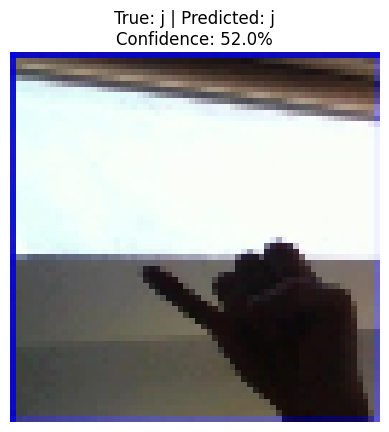

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import joblib
from skimage.feature import hog

# Load improved models
model = joblib.load('rf_hog_best.pkl')   # ya 'rf_hog_best.pkl'
scaler_hog = joblib.load('scaler_hog.pkl')
pca_hog = joblib.load('pca_hog.pkl')
le = joblib.load('label_encoder.pkl')

# Function to extract HOG from a single image
def extract_hog_single(img_flat, img_size=(64,64)):
    img = img_flat.reshape(img_size[0], img_size[1], 3)
    gray = np.dot(img[...,:3], [0.2989, 0.5870, 0.1140])
    fd = hog(gray, orientations=9, pixels_per_cell=(8,8),
             cells_per_block=(2,2), visualize=False)
    return fd

# Pick a random test sample from original X_test (not PCA version)
idx = np.random.randint(0, len(X_test))
true_label = le.inverse_transform([y_test[idx]])[0]

# Extract HOG from the test image
hog_feat = extract_hog_single(X_test[idx])
hog_scaled = scaler_hog.transform([hog_feat])
hog_pca = pca_hog.transform(hog_scaled)

# Predict
pred_idx = model.predict(hog_pca)[0]
pred_label = le.inverse_transform([pred_idx])[0]
confidence = np.max(model.predict_proba(hog_pca)[0]) * 100

# Display image 
img = X_test[idx].reshape(64,64,3).astype(np.float32)
plt.imshow(img)
plt.title(f"True: {true_label} | Predicted: {pred_label}\nConfidence: {confidence:.1f}%")
plt.axis('off')
plt.show()

In [16]:
from sklearn.ensemble import VotingClassifier
import joblib
# Create ensemble with KNN and RF only
ensemble_knn_rf = VotingClassifier(
    estimators=[('knn', knn_hog.best_estimator_), ('rf', rf_hog)],
    voting='soft'   # probabilities average
)
ensemble_knn_rf.fit(X_train_hog_pca, y_train)

# Evaluate
from sklearn.metrics import accuracy_score
y_pred_ensemble = ensemble_knn_rf.predict(X_test_hog_pca)
acc_ensemble_knn_rf = accuracy_score(y_test, y_pred_ensemble)
print(f"Ensemble (KNN + RF) Accuracy: {acc_ensemble_knn_rf:.4f}")
print(f"KNN alone: {acc_knn_hog:.4f}")
print(f"RF alone:  {acc_rf_hog:.4f}")

joblib.dump(ensemble_knn_rf, 'ensemble_knn_rf.pkl')
print("Ensemble (KNN+RF) model saved as 'ensemble_knn_rf.pkl'")

Ensemble (KNN + RF) Accuracy: 0.8946
KNN alone: 0.8886
RF alone:  0.8675
Ensemble (KNN+RF) model saved as 'ensemble_knn_rf.pkl'


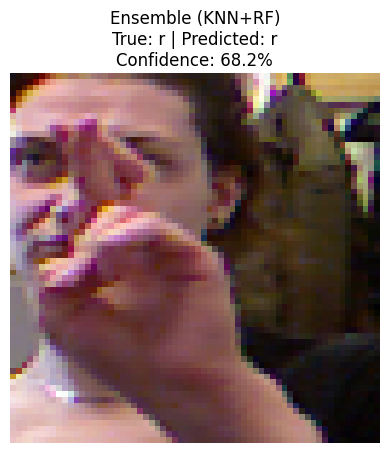

True label: r
Predicted : r
Confidence: 68.19%


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import joblib
from skimage.feature import hog

# Load ensemble model and preprocessors
ensemble_model = joblib.load('ensemble_knn_rf.pkl')
scaler_hog = joblib.load('scaler_hog.pkl')
pca_hog = joblib.load('pca_hog.pkl')
le = joblib.load('label_encoder.pkl')

# Function to extract HOG from a single image (same as before)
def extract_hog_single(img_flat, img_size=(64,64)):
    img = img_flat.reshape(img_size[0], img_size[1], 3)
    gray = np.dot(img[...,:3], [0.2989, 0.5870, 0.1140])
    fd = hog(gray, orientations=9, pixels_per_cell=(8,8),
             cells_per_block=(2,2), visualize=False)
    return fd

# Pick a random test sample from original X_test (not PCA version)
idx = np.random.randint(0, len(X_test))
true_label = le.inverse_transform([y_test[idx]])[0]

# Extract HOG from the test image
hog_feat = extract_hog_single(X_test[idx])
hog_scaled = scaler_hog.transform([hog_feat])
hog_pca = pca_hog.transform(hog_scaled)

# Predict using ensemble
pred_idx = ensemble_model.predict(hog_pca)[0]
pred_label = le.inverse_transform([pred_idx])[0]
confidence = np.max(ensemble_model.predict_proba(hog_pca)[0]) * 100

# Display image
img = X_test[idx].reshape(64,64,3).astype(np.float32)
plt.imshow(img)
plt.title(f"Ensemble (KNN+RF)\nTrue: {true_label} | Predicted: {pred_label}\nConfidence: {confidence:.1f}%")
plt.axis('off')
plt.show()

print(f"True label: {true_label}")
print(f"Predicted : {pred_label}")
print(f"Confidence: {confidence:.2f}%")